### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2026-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

***

### ⚠️ General guidelines for TPs

Each team shall upload its report on [Teide](https://teide.ensimag.fr/) before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP1: Analysis of prostate cancer data

A medical study done on patients with prostate cancer aims to analyze the correlation between the prostate tumor volume and a set of clinical and morphometric variables. These variables include prostate specific antigens, a biomarker for prostate cancer, and a number of clinical measures (age, prostate weight, etc). The goal of this lab is to build a regression model to predict the severity of cancer, expressed by logarithm of the tumor volume -- `lcavol` variable -- from the following predictors:
- `lpsa`: log of a prostate specific antigen
- `lweight`: log of prostate weight
- `age`: age of the patient
- `lbph`: log of benign prostatic hyperplasia amount
- `svi`: seminal vesicle invasion
- `lcp`: log of capsular penetration
- `gleason`: Gleason score (score on a cancer prognosis test)
- `pgg45`: percent of Gleason scores 4 or 5

The file `prostate.data`, available [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP1/prostate.data), contains measures of the logarithm of the tumor
volume and of the 8 predictors for 97 patients. This file also contains an additional variable, called `train`, which will
not be used and has to be removed.

In [1]:
# All libraries import here
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

import statsmodels.api as sm

from scipy import stats

import seaborn as sns

from itertools import combinations

# Exercise 4
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

## ▶️ Exercise 1: Preliminary analysis of the data (1 points)

**(a)** Download the file `prostate.data` and store it in your current folder. Read the dataset in using `pandas` as per
```
import pandas as pd
df = pd.read_csv("prostate.data", sep="\t")
```
check how to use function `df.drop` to remove the first and last columns of `df` containing useless tags.

In [2]:
df = pd.read_csv("prostate.data", sep="\t")

indices = [0, len(df.columns)-1]
df = df.drop(df.columns[indices], axis=1)
df

,lcavol,lweight,age,lbph,svi,lcp,gleason,pgg45,lpsa
0,-0.579818,2.769459,50,-1.386294,0,-1.386294,6,0,-0.430783
1,-0.994252,3.319626,58,-1.386294,0,-1.386294,6,0,-0.162519
2,-0.510826,2.691243,74,-1.386294,0,-1.386294,7,20,-0.162519
3,-1.203973,3.282789,58,-1.386294,0,-1.386294,6,0,-0.162519
4,0.751416,3.432373,62,-1.386294,0,-1.386294,6,0,0.371564
...,...,...,...,...,...,...,...,...,...
92,2.830268,3.876396,68,-1.386294,1,1.321756,7,60,4.385147
93,3.821004,3.896909,44,-1.386294,1,2.169054,7,40,4.684443
94,2.907447,3.396185,52,-1.386294,1,2.463853,7,10,5.143124
95,2.882564,3.773910,68,1.558145,1,1.558145,7,80,5.477509


**(b)** The function defined below generates scatterplots (clouds of points) between all pairs of variables, allowing us to visually analyse the correlations between all variables in the dataframe. Explain what each line of function `pairplot` does and how it affects the final plot. You can use command `help` in the `python` shell to get the documentation of each function.

``` 
# import the main plotting library for python
import matplotlib.pyplot as plt

# make a pairplot from scratch
def pairplot(df, figsize=None):
    if figsize is None:
        figsize = (7.10, 6.70)
    n_vars = df.shape[1]
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    plt.subplots_adjust(
        wspace=0.10, hspace=0.10, left=0.05, right=0.95, bottom=0.05, top=0.95)
    for i in range(n_vars):
        for j in range(n_vars):
            axij = ax[i][j]
            i_name = df.columns[i]
            j_name = df.columns[j]
            axij.set_xticks([])
            axij.set_yticks([])
            axij.margins(0.1)
            if i != j:
                axij.scatter(df[i_name], df[j_name], s=10)
            else:
                axij.text(0.5, 0.5, i_name, fontsize=10,
                              horizontalalignment='center',
                              verticalalignment='center',
                              transform = axij.transAxes)        
    return fig, ax

fig, ax = pairplot(df)
plt.show()
```

/Users/ousmanediakite/anaconda3/envs/isla2026/lib/python3.10/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


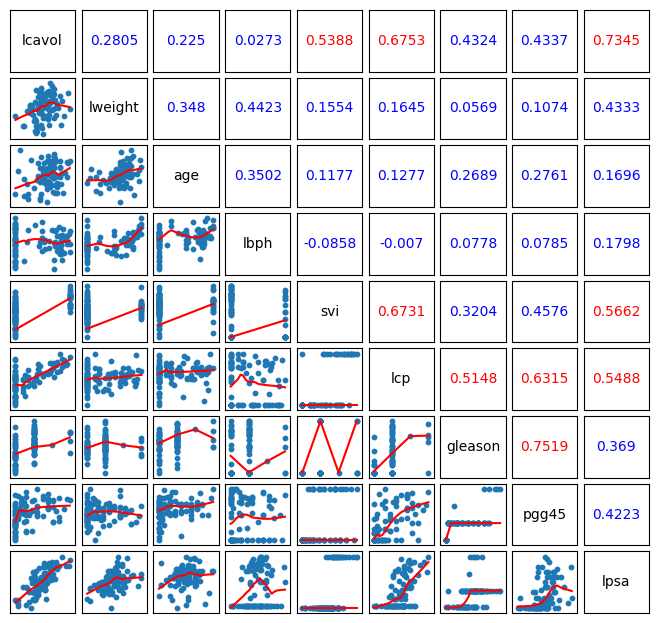

In [3]:
# make a pairplot from scratch
def pairplot(df, figsize=None):
    # Verify if the figure's size is defined. Otherwise create it
    if figsize is None:
        figsize = (7.10, 6.70) # (width, height)
    # Save the number of variable (columns) of df in n_vars
    n_vars = df.shape[1]

    # Create a grid of size n_vars x n_vars and return two arguments : fig -> the figure content in each case of grid and ax -> an array which contains axes (X,Y) of each case
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    # Adjustment
    plt.subplots_adjust(
        wspace=0.10, hspace=0.10, left=0.05, right=0.95, bottom=0.05, top=0.95)
    
    # We're going to represent name of every column and its scatter in grid created
    for i in range(n_vars):
        for j in range(n_vars):
            # Obtain the coordinate of current case by ax
            axij = ax[i][j]
            # Get the name of column at place i and j
            i_name = df.columns[i]
            j_name = df.columns[j]
            # Remove coord x and y graduations in every axe
            axij.set_xticks([])
            axij.set_yticks([])
            axij.margins(0.1)
            if i == j:
                # Write the name of parameter in the middle of the case where index i equals j 
                axij.text(0.5, 0.5, i_name, fontsize=10,
                              horizontalalignment='center',
                              verticalalignment='center',
                              transform = axij.transAxes) 
            # Representation of point's scatter between 2 differents parameters
            elif i < j:
                # Upper triangle of subplots
                r = df[i_name].corr(df[j_name])
                r_arrondi = round(r, 4)
                # write the result at the center of case
                axij.text(0.5, 0.5, r_arrondi, fontsize=10, color='red' if r_arrondi>0.5 else 'blue',
                          ha= 'center',
                          va= 'center',
                          transform= axij.transAxes)
            else:
                # low triangle of subplots
                axij.scatter(df[i_name], df[j_name], s=10)

                #BONUS
                smooth = lowess(df[j_name], df[i_name], frac=0.5)
                axij.plot(smooth[:, 0], smooth[:, 1], color='red', lw=1.5)
                       
    return fig, ax

# The pairplot function receives a DataFrame, but it creates and manipulates Figure and Axes objects. Using axij.scatter() or axij.text(), 
# the function directly modifies the properties of these objects. Since these objects are returned at the end (return fig, ax), the user can
# continue to modify them or ask Matplotlib to render (draw) them on the screen. And there we can use plt.show()
# So now, plt.show() isn't very important.

fig, ax = pairplot(df)
plt.show()

**(c)** Based on the generated figure, identify which variables seem the most correlated to `lcavol`. Also, infer the datatype for each of the predictors.

<font color = green> The variable which seem the most correlated to 'lcavol' is 'lpsa' because almost all points go up to the right (so positive correlation). They're almost aligned.

<font color =green> Let's infer the datatype for each of predictors.

Numerical variable : lcavol, lweight, age, lbph, lcp, lpsa, pgg45, gleason

Binary or boolean variable : svi (we just have points aligned vertically or horizontally. So yes or No)

**(d)** Recall the formula of correlation between two vectors and implement it with `numpy`. Explain the difference of your result when compared to `df.corr()`. Change the function `pairplot`to show the correlation coefficient on the upper triangle of the subplots. (Bonus) Use locally weighted scatterplot smoothing (LOWESS) to see the trends between pairs of features with `statsmodels.nonparametric.smoothers_lowess`.

<font color=green> Formula of correlation between twon vectors

\begin{align*}
\rho_{X,Y} &= \frac{cov(X,Y)}{\sigma_X \sigma_Y} \\
&= \frac{\sum_{i=1}^n(x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum_{i=1}^n(x_i-\bar{x})²} \sqrt{\sum_{i=1}^n(y_i-\bar{y})²}}
\end{align*}

In [4]:
def manual_corr(x, y):
    x_mean, y_mean = np.mean(x), np.mean(y)
    num = np.sum((x-x_mean)*(y-y_mean))
    denom = np.sqrt(np.sum((x-x_mean)**2)*np.sum((y-y_mean)**2))

    return num / denom

corr = manual_corr(df['lcavol'], df['lpsa'])
print(df['lcavol'].corr(df['lpsa']))
print(corr)

0.734460326213673
0.7344603262136731


<font color=green> Difference between corr with numpy and df.corr

Here we have the same result from both numy and df.corr() because we don't have any NaN value in our data. But if data contain NaN the function with numpy (manual_corr here) will return NaN. But df.corr() automatically drop NaN and compute without them.

## ▶️ Exercise 2: Linear regression (7 points)

In this exercise, we will perform a multiple linear regression to build a predictive model for the `lcavol` variable. The variables `gleason` and `svi` should be considered as qualitative variables. You can declare them as such with

```
df['svi'] = df['svi'].astype("category")
df['gleason'] = df['gleason'].astype("category")
```

**(a)** Provide the mathematical equation of the regression model (note that you can use LaTeX to write equations) and define the diﬀerent parameters. 

In [5]:
df['svi'] = df['svi'].astype("category")
df['gleason'] = df['gleason'].astype("category")

<font color=green> Equation of the regression model
\begin{align*}
y_i = \beta_0 + \sum_{j=1}^p \beta_jx_{ij} + \epsilon_i
\end{align*}

- $y_i$ is the dependant variable that we want to predict. So `lcavol`
- $\beta_0$ is the intercept. The predicted value of lcavol when all numerical predicters are zero
- $\beta_i$ is regression coefficient of quantitative variable i. It measure the impact of a one-unit increase in the variable on lcavol 
- $\epsilon_i$ is the error. It represent the difference between the real value and predicted value by the model for person i.

Now with our context, the regression equation becomes :

\begin{align*}
lcavol_i = \beta_0 + \beta_1 lweight_i + \beta_2 age_i + \beta_3 lbph_i + \beta_4 pgg45_i + \beta_6 lpsa_i + \sum_{k=1}^{K-1} \gamma_k D_{ki} + \epsilon_i
\end{align*}

NB : $D_{ki}$ represent the qualitative variables (`svi` and `gleason`) and K is number of categories contained in each qualitative variable.

**(b)** Before doing the linear regression of this TP, you will first have to handle the one-hot encoding of the categorical features of the dataframe. One way of doing this is as follows:

```
# encode the categorical features with dummy variables
df_enc = pd.get_dummies(df, dtype=np.float64)
# to drop one dummy column for each predictor
df_enc = df_enc.drop(columns=['svi_0', 'gleason_6'])
# add a column of ones to the dataframe
df_enc['intercept'] = 1
# extract the dataframe for predictors
X = df_enc.drop(columns=['lcavol'])
# get the observed values to predict
y = df['lcavol']
```

- Why did we fix a `dtype` in `pd.get_dummies`?
- Why did we drop two columns after the encoding?
- Why did we add a column of ones to the dataframe?

<font color=green>1- Fixing of dtype in pd.get_dummies

As the regression model must realise matrix product, by forcing dtype, we ensure that all data is in high-precision numeric format. And this prevents some columns from being integers and others from being floating-point numbers, which could cause errors.

2- Deletion of two columns after encoding
- With the column intercept which is always worth 1, and addition of categorie (svi) columns where result will always be 1 for each line; we'll have repetition of information. So the computer will faced with an impossible equation to solve.
- By deleting svi_0 and gleason_6, we're creating reference category. The intercept $\beta_0$ becomes our starting point. It represents the value of lcavol for "baseline" patient (one who has an svi of 0 and a gleason 6). And the other coefficients become deviations.

3- Addition of a column of ones to the dataframe

For a computer, to calculate all the coefficients ($\beta$) at once using matrix multiplication, it needs each $\beta$ to be associated with a column in our matrix. So by adding a column of ones, we can write the equation like : 
\begin{align*}
lcavol_i = \beta_0.(1) + \beta_1 lweight_i + \beta_2 age_i + \beta_3 lbph_i + \beta_4 pgg45_i + \beta_6 lpsa_i + \sum_{k=1}^{K-1} \gamma_k D_{ki} + \epsilon_i
\end{align*}

In [6]:
# encode the categorical features with dummy variables
df_enc = pd.get_dummies(df, dtype=np.float64)
# to drop one dummy column for each predictor
df_enc = df_enc.drop(columns=['svi_0', 'gleason_6'])
# add a column of ones to the dataframe
df_enc['intercept'] = 1
# extract the dataframe for predictors
X = df_enc.drop(columns=['lcavol'])
# get the observed values to predict
y = df['lcavol']

**(c)** We will use the [`statsmodels`](https://www.statsmodels.org/) package to estimate the coefficients of the multiple linear regression as per:

```
# import required package
import statsmodels.api as sm
# this line does not fit the regression model per se but only builds it
model = sm.OLS(y, X)
# now we actually fit the model, e.g. calculate all of regression parameters
results = model.fit()
```

Use command `results.summary()` to get the statistical summary of the estimated coefficients. 

- Explain to what correspond the regression coeﬃcients for the lines related to `svi` and `gleason`. 

- What would have happened in the regression if we did not do the one-hot encoding from above?

- Comment the overall results of the regression as well.

In [7]:
model = sm.OLS(y,X)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                 lcavol   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.650
Method:                 Least Squares   F-statistic:                     18.83
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           9.05e-18
Time:                        13:36:58   Log-Likelihood:                -96.825
No. Observations:                  97   AIC:                             215.7
Df Residuals:                      86   BIC:                             244.0
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
lweight       -0.0112      0.211     -0.053      0.9

<font color=green> 1- Interpretation of svi and gleason's regression coeficient
- svi_1 (-0.2204): it represents the average difference of lcavol between a patient with svi_1 and a paient who doesn't have (svi_0). But this value is not signicant because of the value of p-value (0.392).
- gleason_7, 8, 9 : Thse coefficients compare each score to the reference score gleason_6.
For example gleason_9 (0.7901), suggest that a patient with score 9 has a lcvol greater than 0.79 compare to a patient with score 6. However, this value also isn't significant because of its p-value (0.109)

2- What would have happened in the regression if we did not do the one-hot encoding from above?
- The model would have assumed that a 1 point increase in gleason always has the same impact (e.g: going from 6 to 7 would be identical to going from 8 to 9).
- It would've calculated only one coefficient for gleason. With the encoding, we could see that gleason_8 has a negative coefficient while gleason_9 is positive.

3- Comment on the overall results of the regression as well.
- Global quality ($R²=0.686$) : The model explains about 68.6% of lcavol variance. That's pretty good for medical data.
- Global significance (Prob($F$-statistic) = $9.05e-18$) : since it's extremely close to zero, so we can say that the model is generally very efficient and that our predictors actually provide information. 
- Significant variables : lpsa and lcp with $p=0.000$ are very significant, as the correlation matrix predicted; age ($p=0.030$) and pgg45($p=0.040$) are significant but theirs impact est low.
- Cond. No. (884) : it's indicator used to detect multicollinearity in regression model.So with the value 884, we can say that there're multicollinearity, which can make individual coefficients unstable.

**(d)** Use `results.conf_int` to get confidence intervals of level 95% for all the coeﬃcients of the predictors. Comment the results.

In [8]:
results.conf_int()

,0,1
lweight,-0.431600,0.409107
age,0.002436,0.047129
lbph,-0.219914,0.011515
lcp,0.233639,0.571880
pgg45,-0.018469,-0.000419
lpsa,0.370474,0.728673
svi_1,-0.730029,0.289190
gleason_7,-0.116263,0.739616
gleason_8,-2.219087,0.797911
gleason_9,-0.179004,1.759273


<font color =green> COMMENT ON THE RESULTS OF CONFIDENCE INTERVALS
- The variables age, lcp, pgg45, lpsa are significant because the two values at the boundaries of their confidence intervals have the same sign. The others aren't significant.
- Estimation is accurate for example variable age and pgg45 because the distance between the minimum and maximum of their confidence interval is low.

**(e)** What can you say about the eﬀects of the `lpsa` variable? Relate your answer to the $p$-value of a hypothesis test and a confidence interval. You can use `results.pvalues`.

In [9]:
results.pvalues

lweight      9.577075e-01
age          3.014993e-02
lbph         7.695609e-02
lcp          8.577858e-06
pgg45        4.047741e-02
lpsa         2.939241e-08
svi_1        3.922717e-01
gleason_7    1.512950e-01
gleason_8    3.516744e-01
gleason_9    1.087313e-01
intercept    1.113676e-01
dtype: float64

<font color =green> EFFECT OF lpsa BASED ON p-value AND CONFIDENCE INTERVAL
- The $p$-value = 2.939241e-08 : The probability that the value of lpsa coefficient is a stroke of luck is virtually zero. 
- Confidence interval [0.370474, 0.728673] : We're 95% sure that the actual effect is between these two limits.
Finally, lpsa is the most robust predictor in our model. Both the $p$-value and the confidence interval confirm a direct and strong link between increased PSA and increased tumor volume (lcavol).

**(f)** Implement yourself a function that calculates the values of the parameters and their corresponding $p$-values. Bonus: explain why `numpy.linalg.inv` is not necessarily the best choice for estimating the parameters as compared to `numpy.linalg.solve`.

In [10]:
def manual_linear_regression(X, y):
    # Estimation of parameters beta
    beta = np.linalg.solve(X.T @ X, X.T @ y)

    # Calculation of residuals and variance
    y_pred = X @ beta
    residuals = y - y_pred
    n,p = X.shape
    dfreedom = n-p

    # residual variance with degree of freedom equals n-p
    sigma_squared = np.sum(residuals**2) / dfreedom

    # Calculation of coefficients standard errors
    C = np.linalg.inv(X.T @ X)
    std_err = np.sqrt(sigma_squared * np.diag(C))

    # Calculation of t-stats and p-value
    t_stats = beta / std_err
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=dfreedom))

    return beta, p_values
coeffs, p_vals = manual_linear_regression(X, y)
print("Affichage des coefficients")
print(f"{coeffs} \n")
print("Affichage des p_values")
print(p_vals)

Affichage des coefficients
[-0.0112462   0.02478241 -0.10419954  0.40275962 -0.00944383  0.5495731
 -0.22041936  0.31167619 -0.71058822  0.79013455 -1.40665404] 

Affichage des p_values
[9.57707489e-01 3.01499280e-02 7.69560879e-02 8.57785824e-06
 4.04774068e-02 2.93924065e-08 3.92271694e-01 1.51294991e-01
 3.51674448e-01 1.08731299e-01 1.11367559e-01]


<font color=green> numpy.linalg.solve THE BEST CHOICE
- $inv$ calculates the complete inverse before multiplying. Each step adds a micro-error. Or $solve$ directly finds the solution to the linear system, minimizing intermediate steps.
- Inverting a matrix requires approximately three times more calculations than simply solving the associated linear system.

**(g)** Plot the predicted values of `lcavol` as a function of the actual values. For this, you can can use `results.get_prediction` to get predictions over `X` and then get its `predicted_mean` attribute.

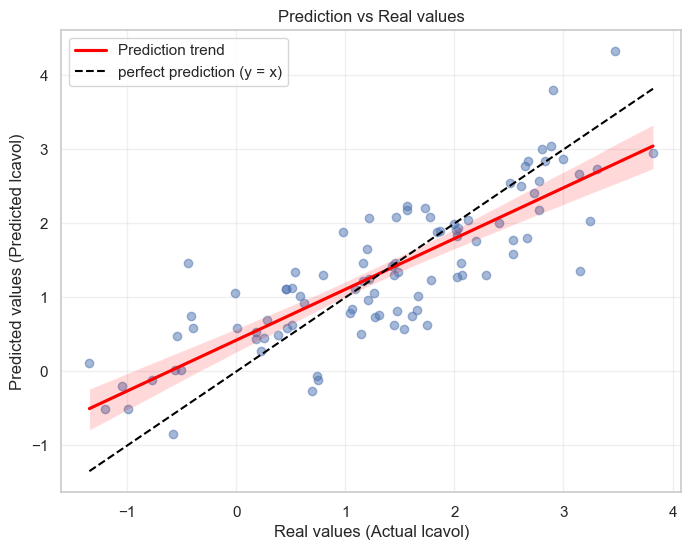

In [11]:
# Retrieve of predictions
pred_obj = results.get_prediction(X)
y_pred = pred_obj.predicted_mean

# Plot the graph
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")
sns.regplot(x=y, y=y_pred, 
            scatter_kws={'alpha':0.5}, 
            line_kws={'label':'Prediction trend','color':'red'})

# sns.scatterplot(x=y, y=y_pred, alpha=0.6)
line_coords =  [y.min(), y.max()]
plt.plot(line_coords, line_coords, color='black', linestyle='--', label='perfect prediction (y = x)')

plt.xlabel('Real values (Actual lcavol)')
plt.ylabel('Predicted values (Predicted lcavol)')
plt.title('Prediction vs Real values')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**(h)** Plot the histogram of residuals as well as their qq-plot using `statsmodels` function `qqplot`. Can we admit that the residuals are normally distributed? Compute the residual sum of squares (RSS).

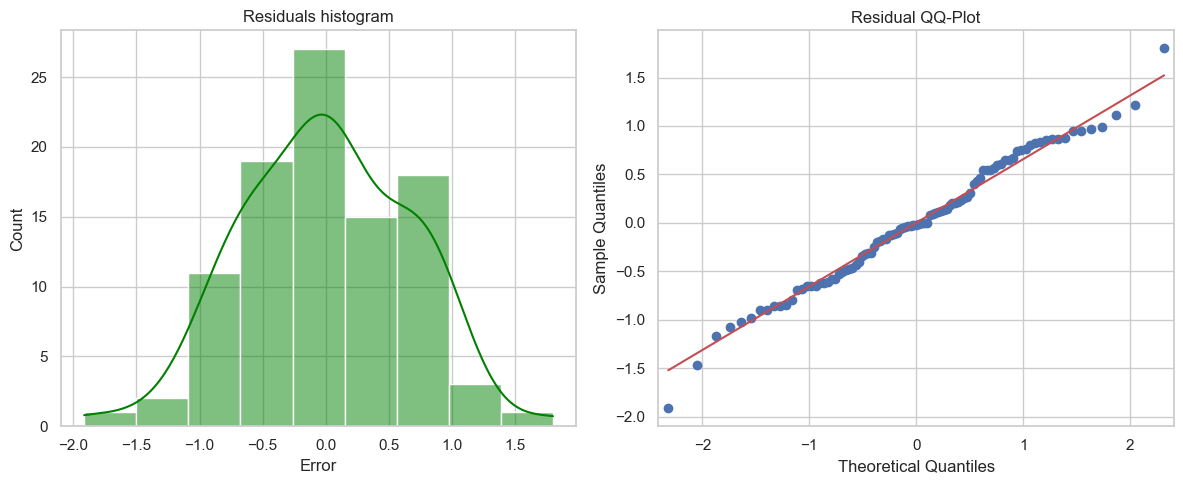

Residual Sum Of Square (RSS) : 41.8141


In [12]:
# Calculation of residuals
residue = results.resid

# Figure creation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
sns.histplot(residue, kde=True, ax=ax1, color='green')
ax1.set_title('Residuals histogram')
ax1.set_xlabel('Error')

# QQ-Plot
sm.qqplot(residue, line='s', ax=ax2)
ax2.set_title('Residual QQ-Plot')

# Automatic adjustment of subplot size and margins
plt.tight_layout()
plt.show()

# Residual sum of square (RSS)
rss = np.sum(residue**2)
print(f"Residual Sum Of Square (RSS) : {rss:.4f}")

# NB: We can have RSS by results.ssr too


<font color=green> CAN WE ADMIT THE NORMALLY DISTRIBUTION OF RESIDUALS ?

Let's see the QQ-Plot

We can saw that the blue points are almost all close to the red "diagonal" line, this means that our errors follow a normal distribution, and therefore our $p$-values are reliable. So YES, we can admit the normally distribution of residuals.

**(i)** What happens if predictors `lpsa` and `lcp` are removed from the multiple linear regression model? Note that you can pass a list of strings to `df.columns.drop` method.

In [13]:
X_reduced = X.drop(columns=['lpsa', 'lcp'])
results_reduced = sm.OLS(y, X_reduced).fit()

print(results_reduced.summary())

# Residual sum of square (RSS)
rss = results_reduced.ssr
print(f"Residual Sum Of Square (RSS) : {rss:.4f}")

                            OLS Regression Results                            
Dep. Variable:                 lcavol   R-squared:                       0.433
Model:                            OLS   Adj. R-squared:                  0.381
Method:                 Least Squares   F-statistic:                     8.390
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           2.11e-08
Time:                        22:39:28   Log-Likelihood:                -125.58
No. Observations:                  97   AIC:                             269.2
Df Residuals:                      88   BIC:                             292.3
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
lweight        0.5850      0.259      2.257      0.0

<font color=green> OBSERVATION WHEN lpsa and lcp ARE REMOVED
- Drop in $R²$ : Since lpsa was the most significant variable, its absence cause the coefficient of determination to drop. So the model explains the variance of lcavol much less effectively.
- Increase in RSS : The total error mechanically increase because the model is less accurate.
- Rebalancing of coefficients : The remaining variables have their coefficient changed and p-values decreased, as the attempt to compensate for the lost information, even though they are less efficient than lpsa
- Aic/ BIC : These information criteria increased, indicating that the model is lower quality despite its greater simplicity.

## ▶️ Exercise 3: Best subset selection (5 points)

A regression model that uses $k$ predictors is said to be of size $k$. For instance, 

$$
\texttt{lcavol} = \beta_1 \texttt{lpsa} + \beta_0 + \varepsilon \quad \text{and} \quad \texttt{lcavol} = \beta_1 \texttt{lweight} + \beta_0 + \varepsilon
$$

are models of size one. The regression model without any predictor $\texttt{lcavol} = \beta_0 + \varepsilon$ is a model of size 0.

The goal of this exercise is to select the best model of size $k$ for each $k \in \{0, \dots, 8\}$.

**(a)** Compute the residual sums of squares (RSS) for all models of size $k = 2$. Which model has the smallest RSS? Note that you can use a generator [`itertools.combination`](https://docs.python.org/3/library/itertools.html#itertools.combinations) to automatize for you all the combinations of $k$ elements among $n$.

**(b)** For each value of $k \in \{0, \dots, 8\}$, select the set of predictors that minimizes the RSS. Plot these values as a function of $k$. Provide the names of the selected predictors for each value of $k$.

**(c)** Do you think that minimizing the residual sum of squares is well suited to select the optimal size for the regression models? Justify your answer using what you've learned in class.

In [14]:
data = pd.read_csv('prostate.data', sep="\t")
data = data.drop(data.columns[[-1, 0]], axis=1)
data['intercept'] = 1

X_9 = data.drop(columns=['lcavol'])


predictors = [col for col in X_9.columns]

# Generation of all combination of size 2
k = 2
combos = list(combinations(predictors, k))

results_list = []

for combo in combos:
    # Selection of columns (size 2) of combinaison
    X_subset = X_9[list(combo)]

    # Model training
    model = sm.OLS(y, X_subset).fit()

    # Save RSS and combo's name
    results_list.append({
        'model' : combo,
        'RSS' : model.ssr
    })

# DataFrame to compare
df_res = pd.DataFrame(results_list)

# Find the best model (low RSS)
best_model = df_res.loc[df_res['RSS'].idxmin()]

print(f"Nombre total de combonaison possibles : {len(combos)}")
print(f"Meilleur modèle de taille {k} : {best_model['model']}")
print(f"RSS correspondant : {best_model['RSS']:.4f}")


Nombre total de combonaison possibles : 36
Meilleur modèle de taille 2 : ('lcp', 'lpsa')
RSS correspondant : 47.3777


                                          predictors         RSS
0                                        [intercept]  133.359034
1                                             [lpsa]   65.855393
2                                        [lcp, lpsa]   47.377697
3                                  [lbph, lcp, lpsa]   46.742128
4                        [age, lcp, lpsa, intercept]   46.237825
5                  [age, lbph, lcp, lpsa, intercept]   44.878406
6           [age, lbph, lcp, pgg45, lpsa, intercept]   44.311332
7  [age, lbph, lcp, gleason, pgg45, lpsa, intercept]   43.354252
8  [age, lbph, svi, lcp, gleason, pgg45, lpsa, in...   43.179048


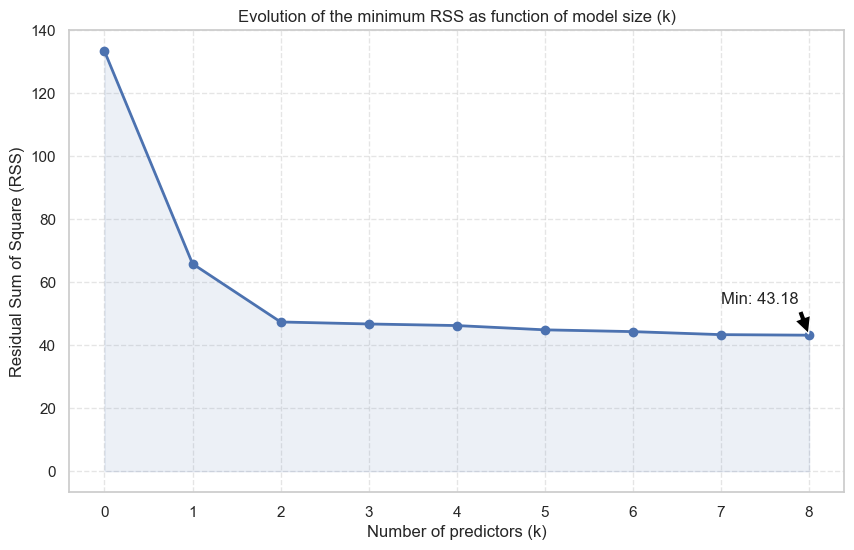

In [15]:
# Dictionnary to save results
best_models = {}
rss_values = []

# case where k=0 (model with only intercept)
model_k0 = sm.OLS(y, X_9['intercept']).fit()
best_models[0] = {'predictors': ['intercept'], 'RSS': model_k0.ssr}
rss_values.append(model_k0.ssr)

# k between 1 and 8 include
for k in range(1, 9):
    best_rss_k = float('inf')
    best_combo_k = None

    for combo in combinations(predictors, k):
        X_subset = X_9[list(combo)]
        model = sm.OLS(y, X_subset).fit()

        if model.ssr < best_rss_k:
            best_rss_k = model.ssr
            best_combo_k = combo
    
    best_models[k] = {'predictors': list(best_combo_k), 'RSS': best_rss_k}
    rss_values.append(best_rss_k)

# Displaying results in table form
df_best = pd.DataFrame.from_dict(best_models, orient='index')
print(df_best)

# Plots
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

plt.plot(range(0, 9), rss_values, marker='o', linestyle='-', color='b', linewidth=2)
plt.fill_between(range(0, 9), rss_values, alpha=0.1, color='b')

plt.title('Evolution of the minimum RSS as function of model size (k)')
plt.xlabel('Number of predictors (k)')
plt.ylabel('Residual Sum of Square (RSS)')
plt.xticks(range(0, 9))
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.annotate(f'Min: {rss_values[-1]:.2f}',
             xy=(8, rss_values[-1]),
             xytext=(7, rss_values[-1]+10),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.show()



<font color=green> IS MINIMIZING THE RESIDUAL SUM OF SQUARES WELL SUITED TO SELECT THE OPTIMAL SIZE FOR THE REGRESSION MODELS ?

- The RSS measures the training error. Mathematically, as soon as we add a predictor to a model --even if it's pure noise unrelated to the target-- the RSS will systematically decrease (or remain the same). So if we only use the RSS, we'll always end up choosing the most complex model, because it's the one that best fits the training data.
- Such a model will have a very low training error, but a very high test (generalization) error.

So to select the optimal model size, the complexity of the model must be penalized.
- Adjust $R²$ : Unlike the classic $R²$ (based on RSS), it only increases if the new variable improves the model more than chance would suggest.
- Information criteria (AIC/ BIC) : these add a mathematical "penalty" based on the number of parameters k. The goal is to minimize these penalties.
- Cross-validation : The model is tested on data it has never seen before to measure its true predictive power.

## ▶️ Exercise 4: Split-validation (5 points)

You have now found the best model for each of the nine possible model sizes. In the following, we wish to compare these nine diﬀerent regression models.

**(a)** Give a brief overview of split-validation: how it works? Why it is not subject to the same issues raised in
the item (c) of the previous Exercise?

**(b)** Use function `train_test_split` from the `sklearn` package to split the dataset into a training and a validation (or test) partition. You can set `test_size=0.3`. For each of the nine models from before (i.e. those that minimized the RSS for each size $k$), compute the mean prediction error calculated over the samples from the test set and compare it to its corresponding mean training error. Plot a curve for each of these error as a function of size $k$. 

**(c)** Based on the previous results, choose the best model for this dataset, giving the parameter estimates for the model trained on the whole dataset (i.e. without splitting), and explain your choice.

**(d)** What is the main limitation of split-validation ? Illustrate this issue on the cancer dataset. What could
you do to address this problem? Code such alternative method and comment the result. Note that `sklearn` can provide you with many choices. See [here](https://scikit-learn.org/stable/model_selection.html) for more information.

<font color=green>
BRIEF OVERVIEW OF SPLIT-VALIDATION

It involves randomly dividing our dataset into two distinct parts :

- The training set : used to estimate the model's beta parameters.
- The validation / Test set : used to evaluate the model's performance on fresh data.

WHY SPLIT-VALIDATION IS NOT SUBJECT TO THE SAME ISSUES RAISED IN THE PREVIOUS EXERCICE ?

Unlike to the training RSS, which mechanically decreases with complexity (k), the test error generally starts to rise again after a certain threshold. This allows for the detection of overfitting : the point at which the model begins to learn the "noise" of the training data instead of the actual structure.

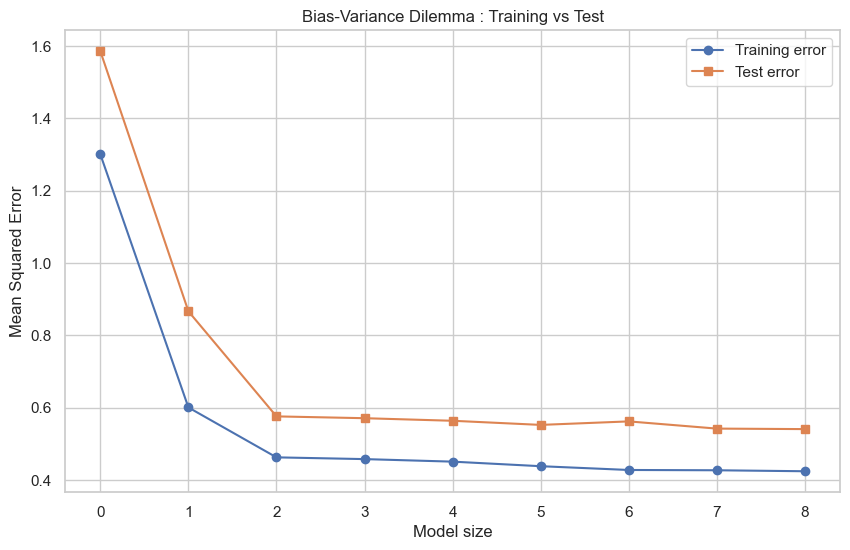

In [16]:
# Split of dataset (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X_9, y, test_size=0.3, random_state=42)

train_errors = []
test_errors = []

for k in range(0, 9):
    pred = list(df_best.loc[k,'predictors'])

    # Training on only Train set
    model = sm.OLS(y_train, X_train[pred]).fit()

    # Calculation of errors (MSE)
    train_pred = model.predict(X_train[pred])
    test_pred = model.predict(X_test[pred])

    train_errors.append(mean_squared_error(y_train, train_pred))
    test_errors.append(mean_squared_error(y_test, test_pred))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(range(0, 9), train_errors, label='Training error', marker='o')
plt.plot(range(0, 9), test_errors, label='Test error', marker='s')
plt.xlabel('Model size')
plt.ylabel('Mean Squared Error')
plt.title('Bias-Variance Dilemma : Training vs Test')
plt.legend()
plt.show()


<font color=green> BEST CHOICE OF k VALUE

The transition from $k=2$ to $k=3$ show that :
- The test error drops dramatically.
- After $k=2$, the curve becomes almost flat (a "plateau").

So the optimal model is probably located at $k=2$ or $k=3$. Beyond that, we increase the complexity for a negligible gain in accuracy on the test set.

Finally the model $k=2$ is the best choice for us. It's more simple, easy to interpret and offer a test error almost same compare to other models with great $k$.

In [17]:
# Best choice
best_k = 2
final_cols = df_best.loc[best_k, 'predictors']
final_model = sm.OLS(y, X_9[final_cols]).fit()
print(f"Meilleur modèle (k={best_k}) :\n", final_model.summary())

Meilleur modèle (k=2) :
                                  OLS Regression Results                                
Dep. Variable:                 lcavol   R-squared (uncentered):                   0.847
Model:                            OLS   Adj. R-squared (uncentered):              0.844
Method:                 Least Squares   F-statistic:                              263.4
Date:                Mon, 23 Feb 2026   Prob (F-statistic):                    1.74e-39
Time:                        22:39:29   Log-Likelihood:                         -102.88
No. Observations:                  97   AIC:                                      209.8
Df Residuals:                      95   BIC:                                      214.9
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------

<font color=green> THE MAIN LIMIT OF SPLIT-VALIDATION

Split-validation is very sensitive to randomness. If we change the random_state, our "best $k$" can change. On a small dataset like this one, removing 30% of data for testing significantly reduces the quality of the training.

SOLUTION (K-FOLD CROSS-VALIDATION)
We divide the data into K pieces (folds). We train the model K times, using each piece as a test set in turn. It's a repetition of several split-validation.

- Round 1 : piece 1 serves as the test; the rest trains the model
- Round 2 : piece 2 serves as the test; the rest trains the model 
- ...and so on until each piece has served as a test once

THe advantage : At the end, we average the K errors. Since each of data has been tested once, the final score is much more reliable and less susceptible to randomness.




In [18]:
# Example with 5-Fold Cross-validation
lr = LinearRegression() # equivalent of sm.OLS but for the Scikit-Learn
# We drop intercept because Scikit automatically add it.
cv_scores = cross_val_score(lr, X_9.drop(columns='intercept'), y, cv=5, scoring='neg_mean_squared_error')
print(f"MSE moyen en Cross-val : {-cv_scores.mean():.4f}")

MSE moyen en Cross-val : 0.5328


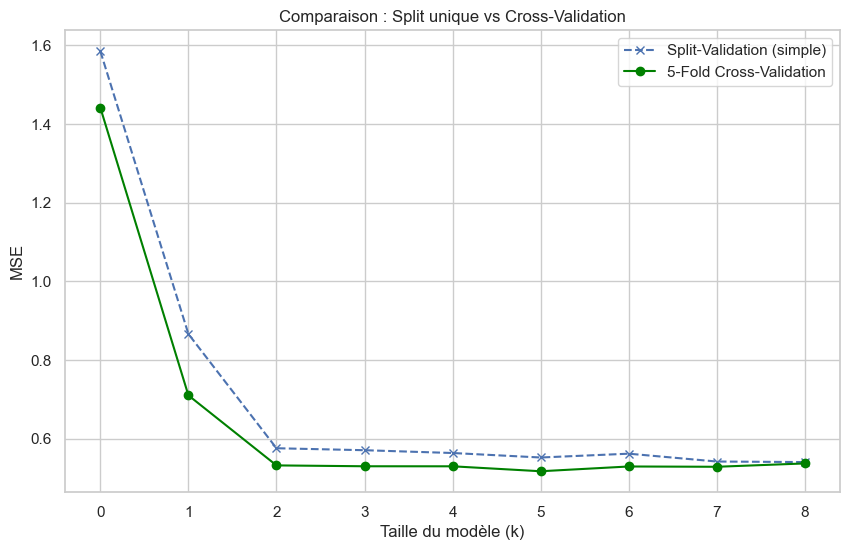

In [19]:
# Configuration of the Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_test_errors = []

for k in range(0, 9):
    # Retrieve the predictors for size k
    cols = list(df_best.loc[k, 'predictors'])
    
    fold_errors = []
    
    # The Cross-Validation loop (we cut 5 times)
    for train_index, test_index in kf.split(X_9):
        # Data separation for this fold
        X_train_cv, X_test_cv = X_9.iloc[train_index], X_9.iloc[test_index]
        y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]
        
        # Training on 4/5 of data
        model = sm.OLS(y_train_cv, X_train_cv[cols]).fit()
        
        # Prediction on the  1/5 remaining
        preds = model.predict(X_test_cv[cols])
        fold_errors.append(mean_squared_error(y_test_cv, preds))
    
    # Back up the error average  of 5 folds
    cv_test_errors.append(np.mean(fold_errors))

# Visualization
plt.figure(figsize=(10, 6))
plt.plot(range(0, 9), test_errors, label='Split-Validation (simple)', marker='x', linestyle='--')
plt.plot(range(0, 9), cv_test_errors, label='5-Fold Cross-Validation', marker='o', color='green')
plt.xlabel('Taille du modèle (k)')
plt.ylabel('MSE')
plt.title('Comparaison : Split unique vs Cross-Validation')
plt.legend()
plt.show()

## ▶️ Exercise 5: Conclusion (2 points)

What is your conclusion about the choice of the best model to predict `lcavol` ? Comment your results.

<font color=green> CONCLUSION ABOUT THE CHOICE OF THE BEST MODEL TO PREDICT lcavol

The model of size $k=2$ is the most appropriate choice for this dataset.

- Bias-Variance Dilemma : our graphs show that the test error drops sharply up to $k=2$ (bias reduction), then pleateaus. Adding variables beyond this point does not improve generalization but increases the model's variance.
- Stability through Cross-validation : The green curve of our $5$-fold cross-validation confirms that the performance gain after $k=2$ is negligible. Unlike the single split, which exhibited oscillations (due to random sampling), the cross-validation shows a stable error, validating the robustness of a simple model.
- In statistic, the simplest model is preferred when performance is equivalent. A $2$-variable model is easier to interpret clinically and less prone to overfitting than an $8$-variable model.
- The fact that lpsa is consistently selected in small models confirms its role as the dominant predictor for lcavol. Variables such as age or gleason score don't provide enough additional information to justify their inclusion in a comprehensive predictive model, as they do not significantly lower the test MSE. 